In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from analysis_by_plot import draw_floorplan
from utils import spl

In [2]:
record_dir = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/yihe/records/'
experiment_id = 'point-goal-noise-paper'

model_names = 'CXonly', 'MB2ONbilateral'
ls_color = 'rb'
n_model = len(model_names)

In [3]:
n_trial = 20
ls_var = 'x', 'y', 'f'

noise_level = 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1

In [4]:
allnoisedata = {}
for trial_id, noise in zip(np.sort(os.listdir(os.path.join(record_dir, experiment_id)))[::-1], noise_level):
    data_dir = os.path.join(record_dir, experiment_id, trial_id)
    noise_motor = noise
    
    alldata = {}
    allnoisedata[noise_motor] = alldata
    for model_name in model_names:
        alldata[model_name] = {'steer': []}
        for var in ls_var:
            alldata[model_name][var] = []

        for trial in range(n_trial):
            data_name = 'Freight_{}_trial_{}_record.npz'.format(model_name, trial)
            data = np.load(os.path.join(data_dir, data_name), allow_pickle=True)
            alldata[model_name]['steer'].append(data['extra'][()]['steer_mode'])
            for var in ls_var:
                alldata[model_name][var].append(data[var])

    scene_name = data['scene_name']
    pos_start_goal = np.transpose([data['pos_start'][:2], data['pos_goal'][:2]])

In [5]:
shortest_dist = np.linalg.norm(pos_start_goal[:, -1] - pos_start_goal[:, 0]) 

Text(0.5, 1.0, 'Pomaria_1_int')

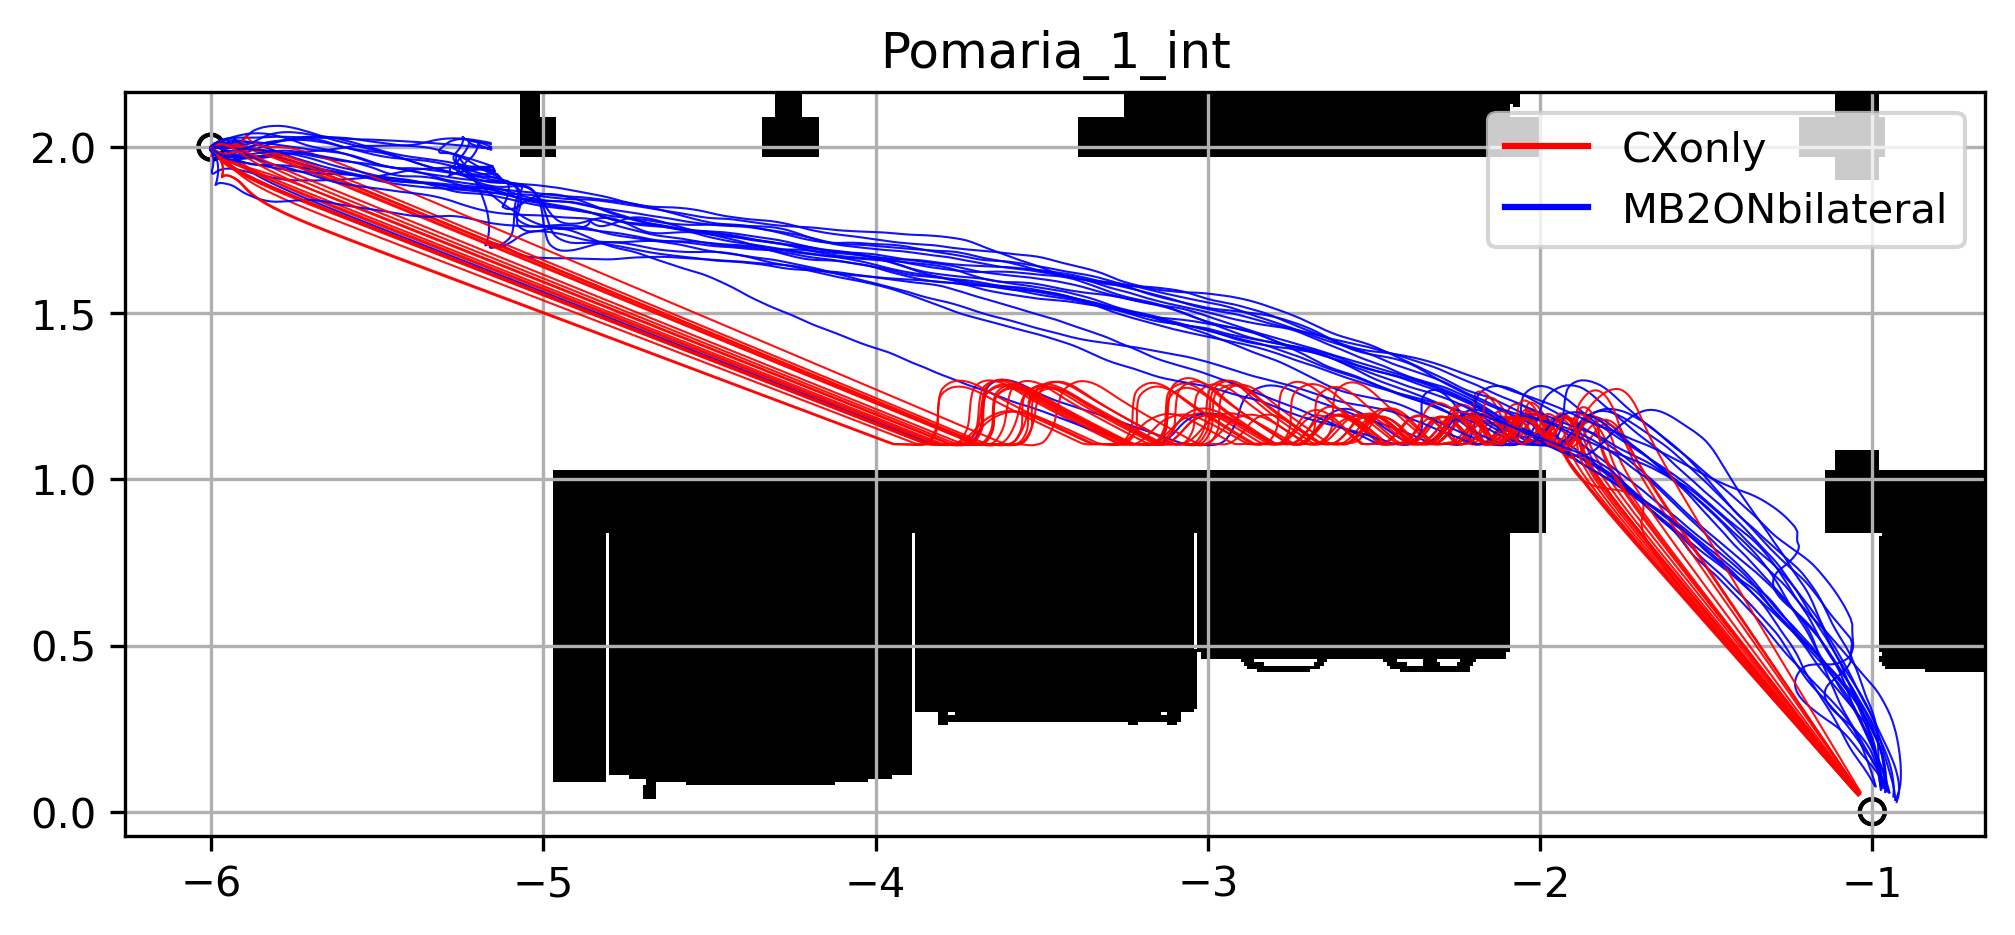

In [6]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
noise = 0.1

for trial in range(n_trial):
    for model_name, color in zip(model_names, ls_color):
        x, y = allnoisedata[noise][model_name]['x'][trial], allnoisedata[noise][model_name]['y'][trial]
        if trial >= -45:
            ax.plot(x, y, 
                    c=color, alpha=0.93, #(trial + 1 + n_trial) / (n_trial * 2),
                    lw=.5)
                        
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
       
    
    
for model_name, color in zip(model_names, ls_color):
    ax.plot([], [], c=color, label=model_name)
    ax.scatter(*pos_start_goal, edgecolor='k', facecolor='none', marker='o')

ax.set_aspect('equal')
ax.legend()

floorplan = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/data/ig_dataset/scenes/{}/layout/floor_trav_no_door_0.png'.format(scene_name)
draw_floorplan(ax, floorplan, 0.01)
ax.set_xlim(xlim)
ax.set_ylim(ylim)    
ax.grid()
ax.set_title(scene_name)

Text(0, 0.5, 'SPL (%)')

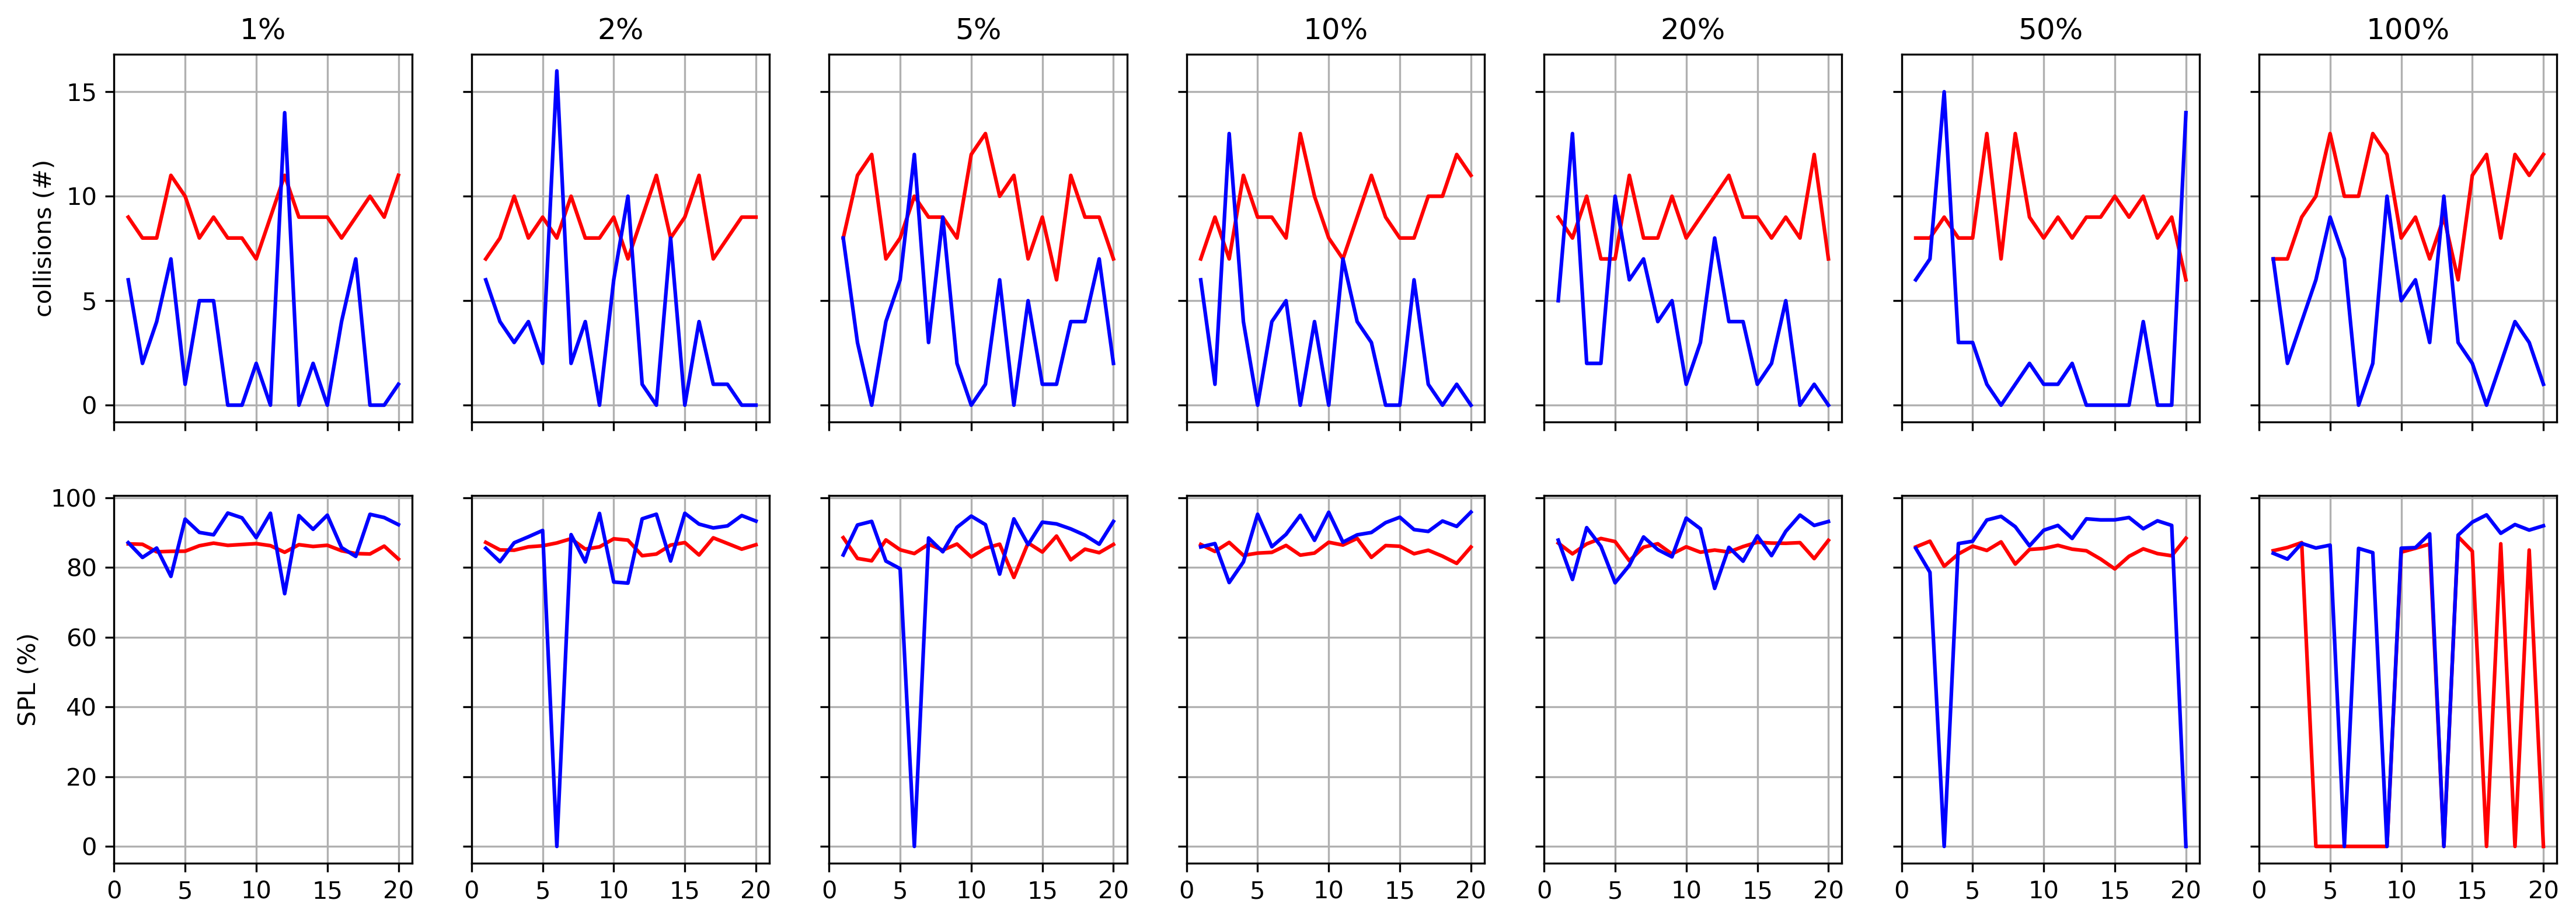

In [7]:
fig, axes = plt.subplots(2, 7, figsize=(18, 6), sharey='row', sharex=True, dpi=300)

data_col = []
data_spl = []

xx = np.arange(1, 21, 1)


for axcol, noise in zip(axes.T, noise_level):
    for model_name, c in zip(model_names, 'rb'):
        n_col = []
        m_spl = []
        xyf = [allnoisedata[noise][model_name][key] for key in 'xyf']
        for x, y, force in zip(*xyf):
            path = np.transpose([x, y])
            n_col.append(np.count_nonzero(force > 100))
            m_spl.append(spl(path, pos_start_goal[:, 1], shortest_dist) * 100)
        axcol[0].plot(xx, n_col, c=c)
        axcol[1].plot(xx, m_spl, c=c)
        
        data_col.append(n_col)
        data_spl.append(m_spl)
        
    axcol[0].set_title('{}%'.format(int(noise * 100)))
    
    for ax in axcol:
        ax.grid()
        ax.set_xticks(np.arange(0, 21, 5))
        
axes[0,0].set_ylabel('collisions (#)')
axes[1,0].set_ylabel('SPL (%)')

In [8]:
data_col_spl = [np.swapaxes(np.reshape(dat, (7, 2, -1)), 0, 1) for dat in (data_col, data_spl)]

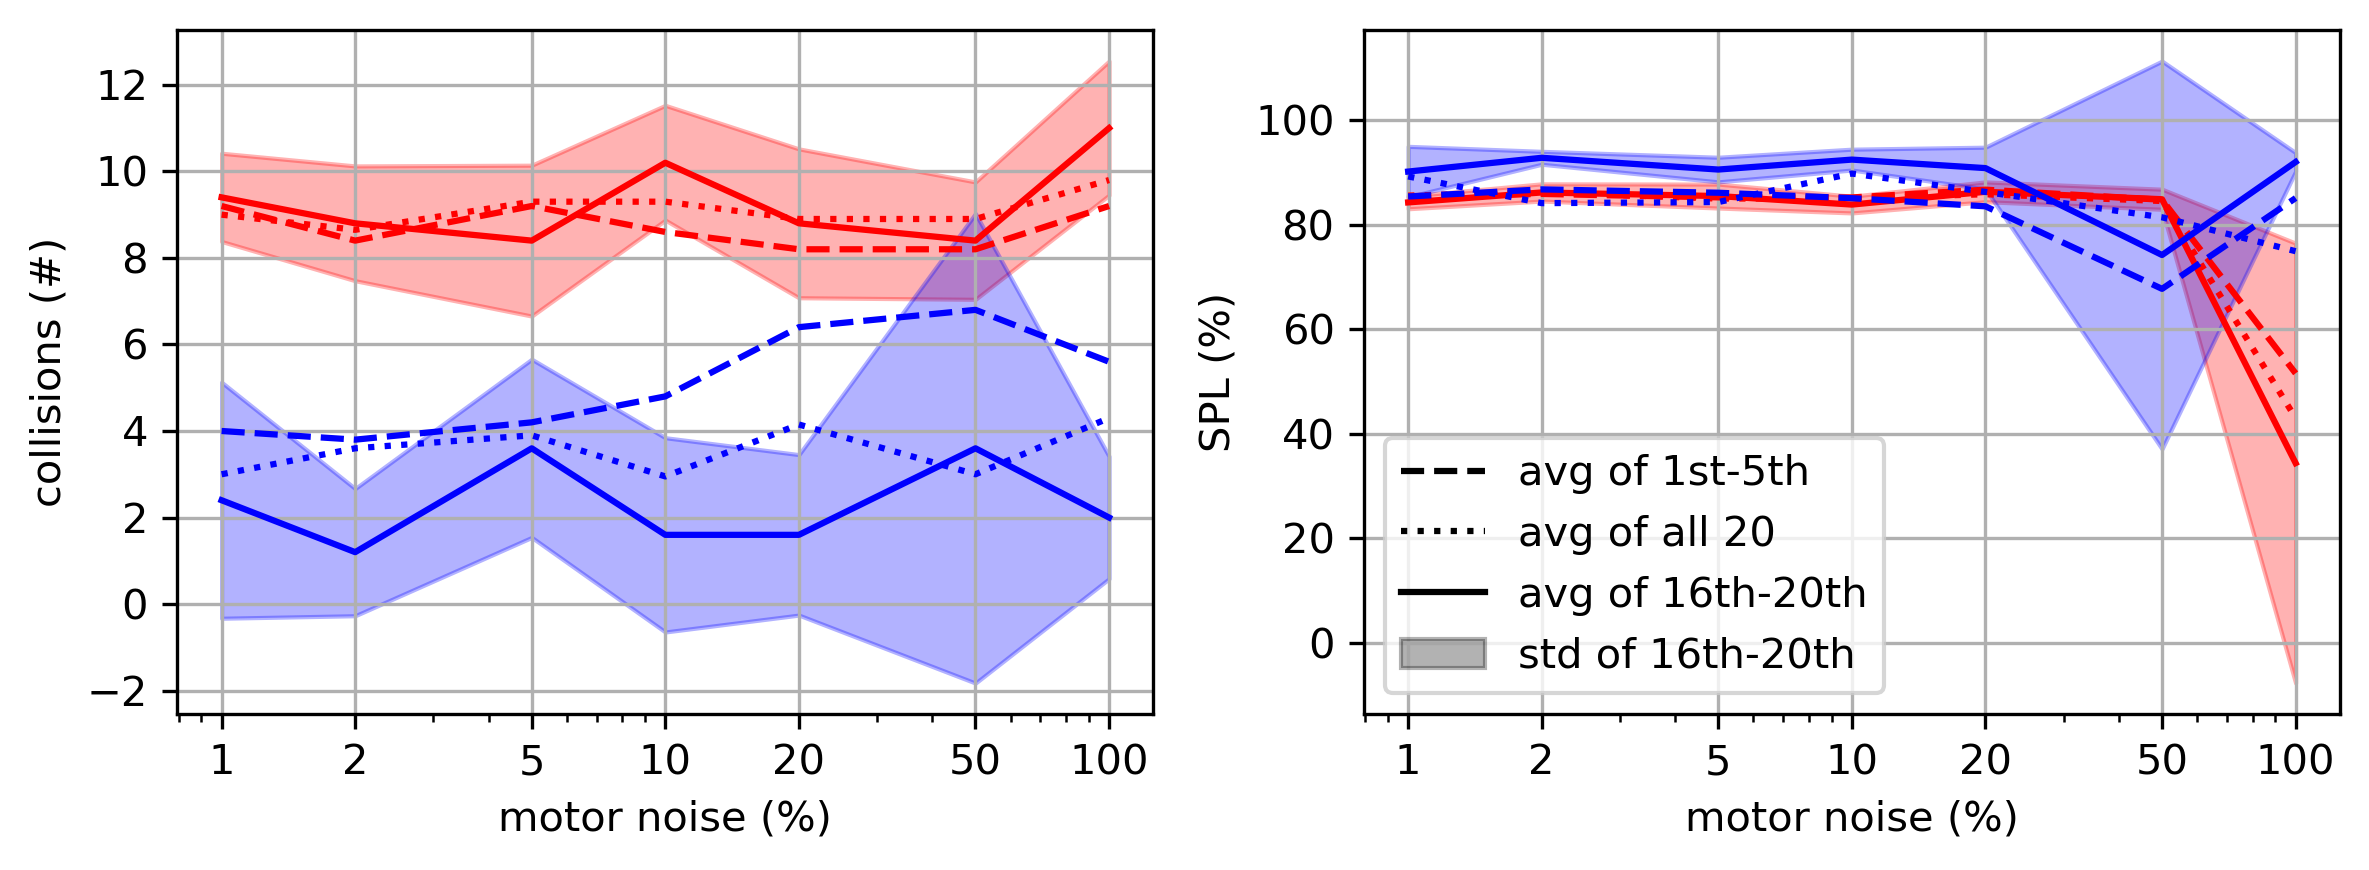

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=300, layout='tight')

for ax, dat in zip(axes, data_col_spl):
    for dc, c in zip(dat, 'rb'):
        yy = np.mean(dc[:, -5:], axis=-1)
        dy = np.std(dc[:, -5:], axis=-1)
        ax.plot(noise_level, yy, c=c)
        ax.fill_between(noise_level, yy - dy, yy + dy, alpha=0.3, color=c)

        ax.plot(noise_level, np.mean(dc[:, :5], axis=-1), c=c, ls='dashed')
        ax.plot(noise_level, np.mean(dc, axis=-1), c=c, ls='dotted')
    
for ax, yl in zip(axes, ('collisions (#)', 'SPL (%)')):
    ax.grid()
    ax.set_ylabel(yl)
    ax.set_xlabel('motor noise (%)')
    ax.set_xscale('log')
    ax.set_xticks(noise_level, np.multiply(noise_level, 100).astype(int))

ax = axes[1]
for ls, lb in zip(['dashed', 'dotted', 'solid'], ['avg of 1st-5th', 'avg of all 20', 'avg of 16th-20th']):
    ax.plot([], [], label=lb, ls=ls, color='k')
ax.fill_between([], [], [], label='std of 16th-20th', color='k', alpha=0.3)
ax.legend()

In [23]:
import json
with open('igibson_noise.json', 'w') as f:
    json.dump(np.array(data_col_spl).tolist(), f)

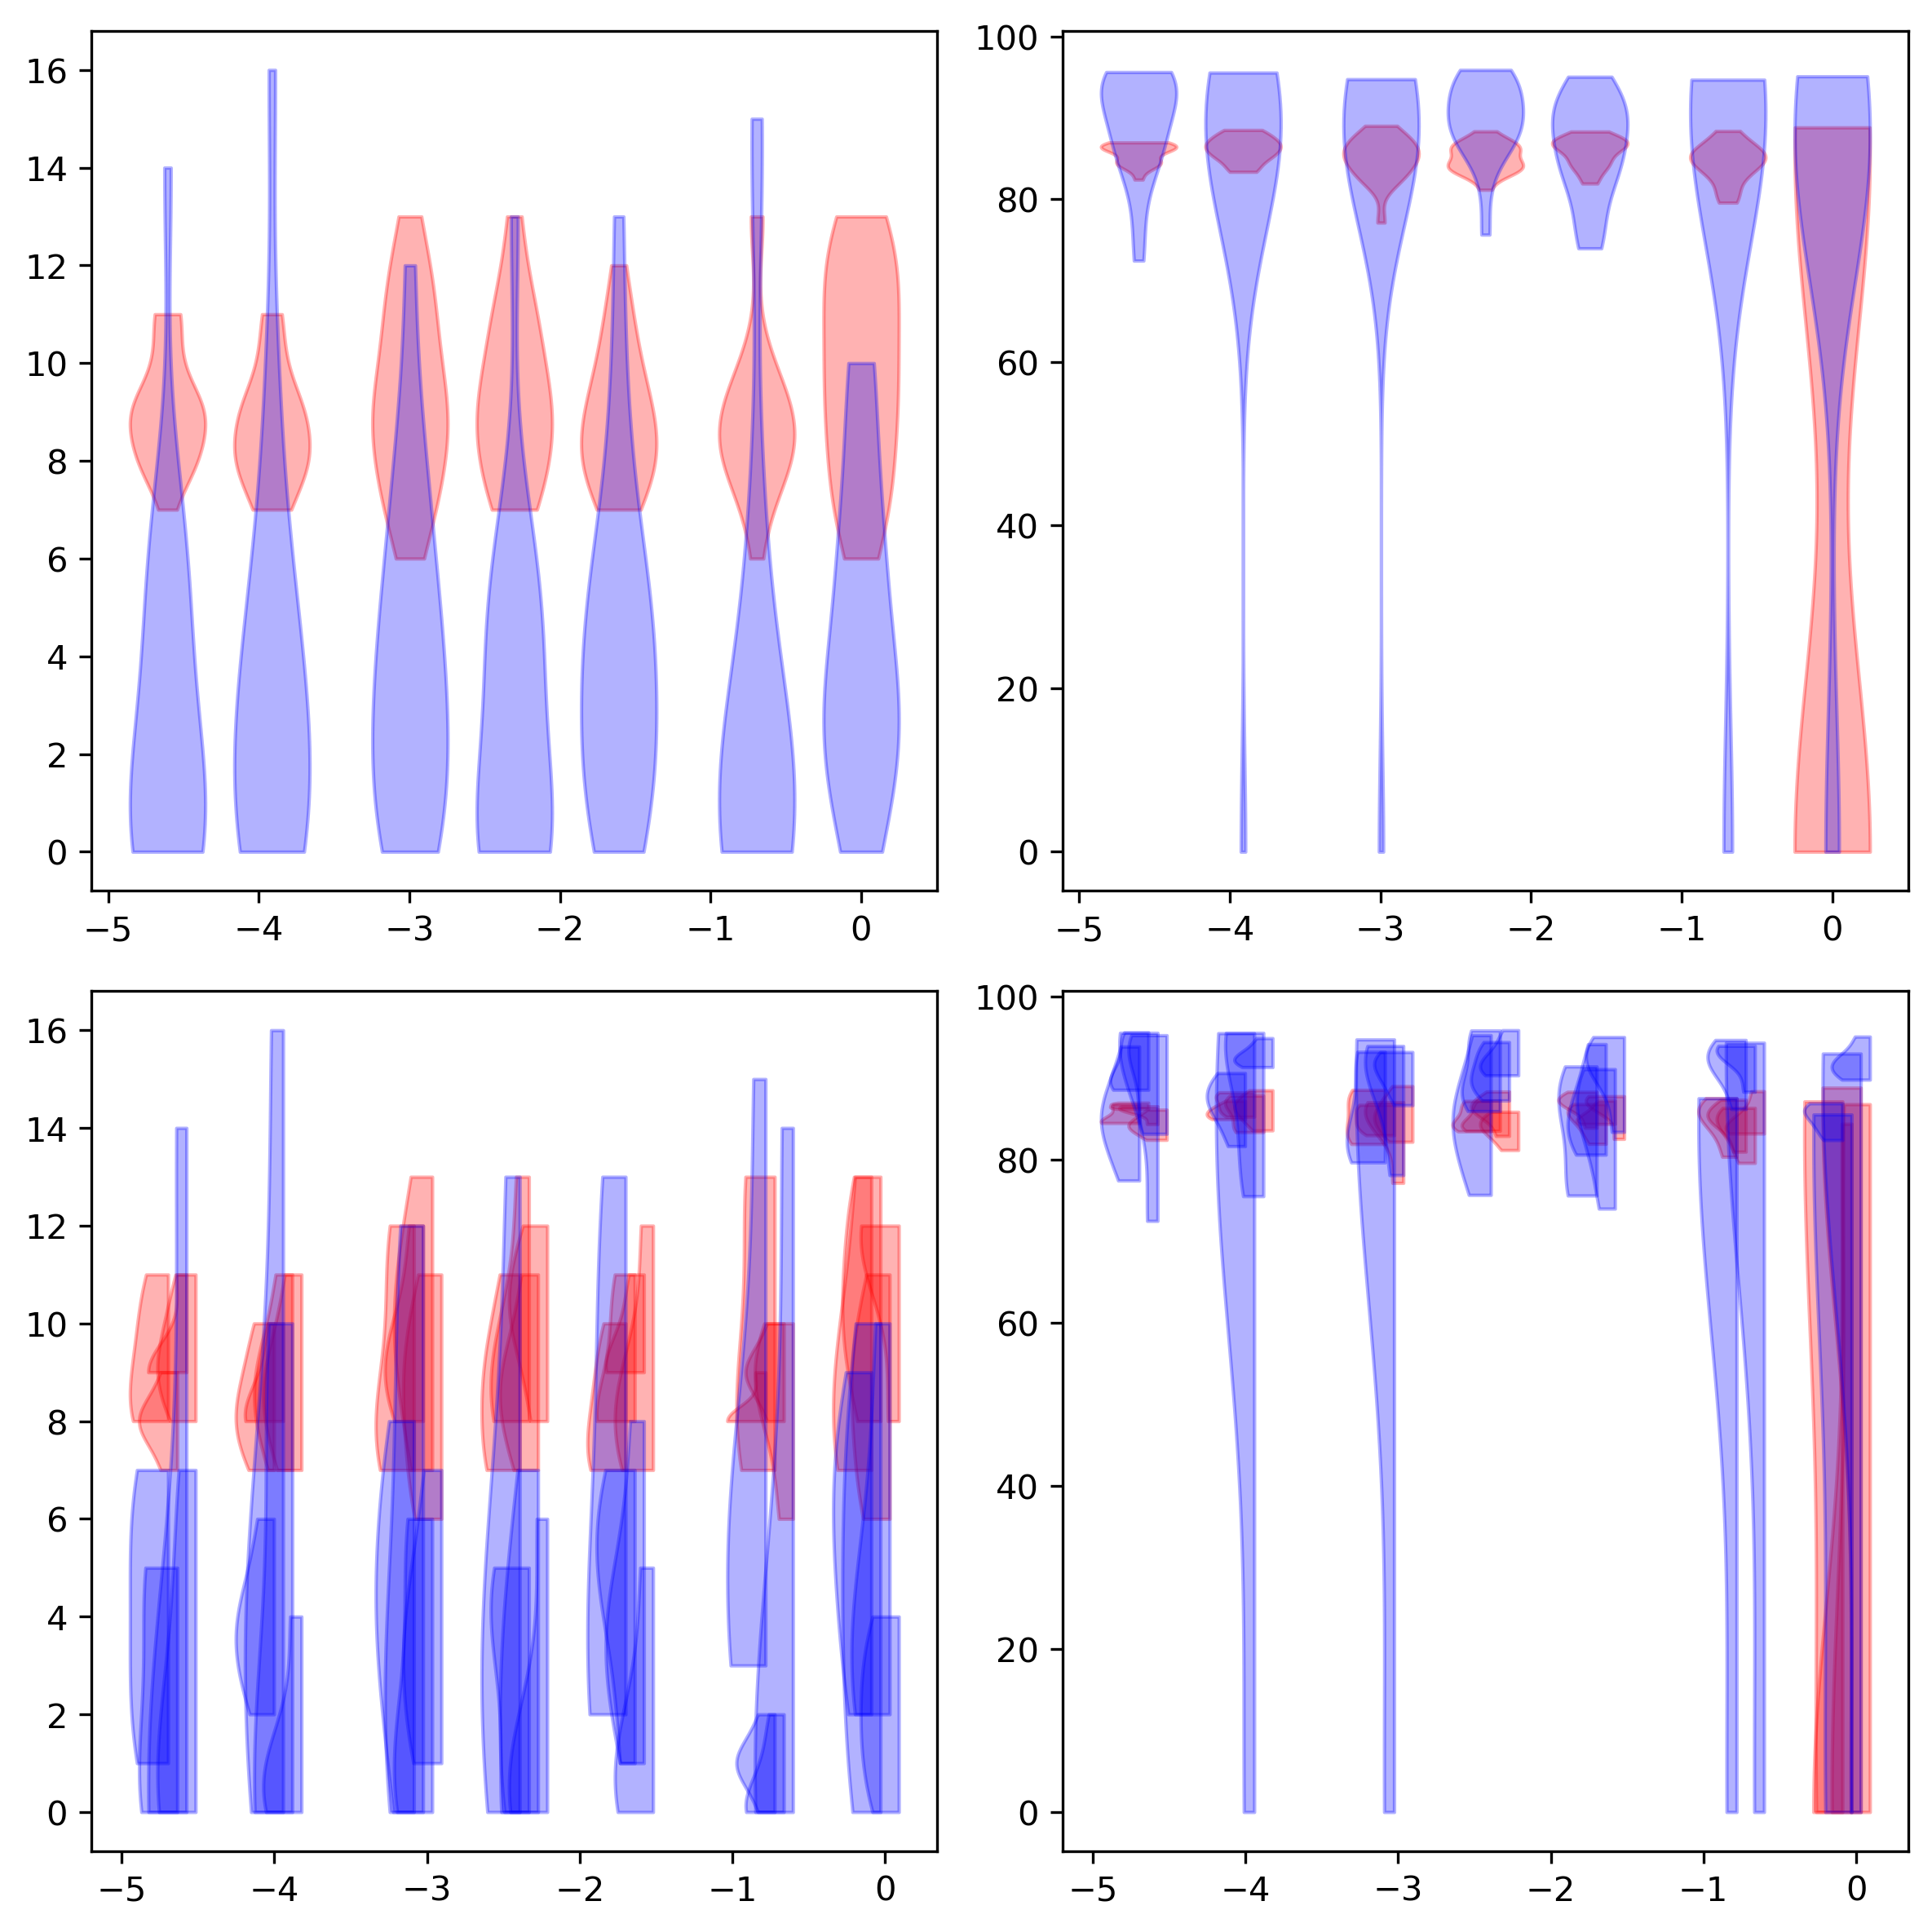

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8), dpi=300, layout='tight')

# for ax, yl in zip(axes, ('collisions (#)', 'SPL (%)')):
#     ax.grid()
#     ax.set_ylabel(yl)
#     ax.set_xlabel('motor noise (%)')
#     ax.set_xscale('log')
#     ax.set_xticks(noise_level, np.multiply(noise_level, 100).astype(int))

xx = np.log(noise_level)
for axcol, dat in zip(axes.T, data_col_spl):
    for dc, c in zip(dat, 'rb'):
        parts=axcol[0].violinplot(dc.T, positions=xx, 
                         showextrema=False, showmeans=False
                         )
        for pc in parts['bodies']:
            pc.set_facecolor(c)
            pc.set_edgecolor(c)
            pc.set_alpha(0.3)        
        for dx, (lo, hi) in zip([-0.09, -0.03, 0.03, 0.09], [(0,5), (5, 10), (10, 15), (15, 20)]):
            parts=axcol[1].violinplot(dc.T[lo:hi], positions=xx + dx, 
                         showextrema=False, showmeans=False, side='low'
                         )
            for pc in parts['bodies']:
                pc.set_facecolor(c)
                pc.set_edgecolor(c)
                pc.set_alpha(0.3)
#     for yy, a in zip(dc.T, np.linspace(1,100,20)):
#         ax.scatter(xx, yy, c='k', s=a, alpha=0.3)
#         ax.fill_between(noise_level, yy - dy, yy + dy, alpha=0.3, color=c)

#         ax.plot(noise_level, np.mean(dc[:, :5], axis=-1), c=c, ls='dashed')
#         ax.plot(noise_level, np.mean(dc, axis=-1), c=c, ls='dotted')
    


# ax = axes[1]
# for ls, lb in zip(['dashed', 'dotted', 'solid'], ['avg of 1st-5th', 'avg of all 20', 'avg of 16th-20th']):
#     ax.plot([], [], label=lb, ls=ls, color='k')
# ax.fill_between([], [], [], label='std of 16th-20th', color='k', alpha=0.3)
# ax.legend()

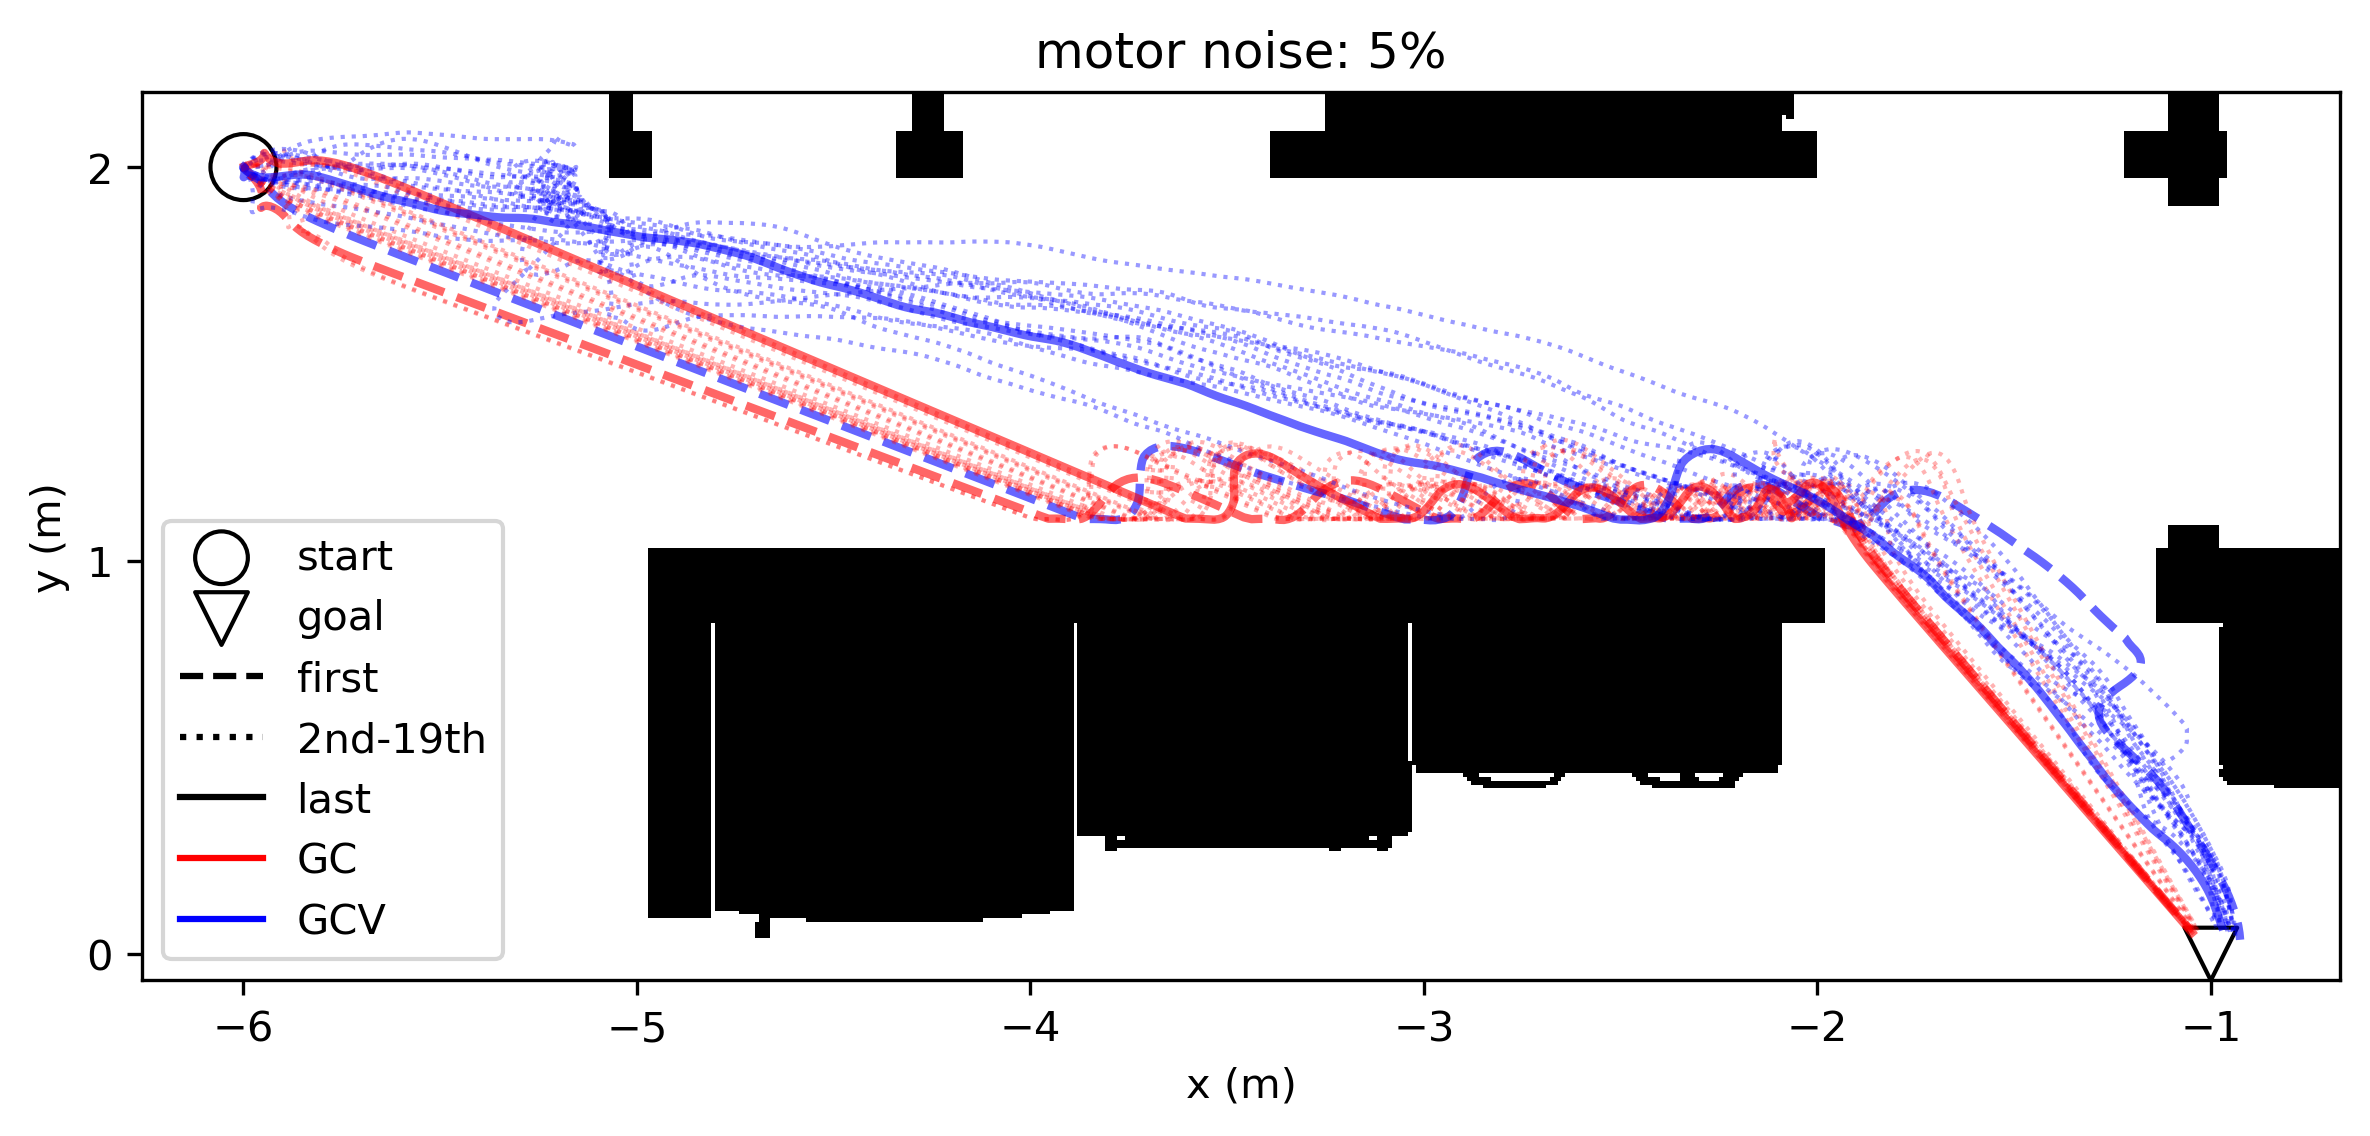

In [10]:
fig, axes = plt.subplot_mosaic('''aa
                                aa''', figsize=(8, 7), dpi=300, layout='tight')

ax = axes['a']

noise = 0.05

for trial in range(n_trial):
    for model_name, color, aa in zip(model_names, ls_color, [0.3, 0.4]):
        x, y = allnoisedata[noise][model_name]['x'][trial], allnoisedata[noise][model_name]['y'][trial]
        if trial == 0:
            ax.plot(x, y, c=color, ls='dashed', lw=2, alpha=0.6)
        elif trial == 19:
            ax.plot(x, y, c=color, ls='solid', lw=2, alpha=0.6)
        else:
            ax.plot(x, y, ls='dotted',
                    c=color, alpha=aa, 
                    lw=1)
                        
    xlim, ylim = ax.get_xlim(), ax.get_ylim()    



body = plt.Circle(pos_start_goal[:, 0], 0.559 / 2 * 0.3, edgecolor='k', facecolor='none')
ax.add_patch(body)
ax.scatter([], [], edgecolor='k', facecolor='none', marker='o', s=160, label='start')

ax.scatter(*pos_start_goal[:, 1], edgecolor='k', facecolor='none', marker='v', s=160, label='goal')

for lb, ls in zip(['first', '2nd-19th', 'last'], ['dashed', 'dotted', 'solid']):
    ax.plot([], [], c='k', ls=ls, label=lb)

for mn, color in zip(['GC', 'GCV'], ls_color):
    ax.plot([], [], c=color, label=mn)

    
    
ax.set_aspect('equal')
ax.legend()

floorplan = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/data/ig_dataset/scenes/{}/layout/floor_trav_no_door_0.png'.format(scene_name)
draw_floorplan(ax, floorplan, 0.01)
ax.set_xlim(xlim)
ax.set_ylim(ylim)    
# ax.grid()
ax.set_title('motor noise: {}%'.format(int(noise*100)))
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_yticks([0,1,2])


# # collision and spl

# for ak, dat, yl in zip('bc', data_col_spl, ('collisions (#)', 'SPL (%)')):
#     ax = axes[ak]
#     for dc, c in zip(dat, 'rb'):
#         yy = np.mean(dc[:, -5:], axis=-1)
#         dy = np.std(dc[:, -5:], axis=-1)
#         ax.plot(noise_level, yy, c=c)
#         ax.fill_between(noise_level, yy - dy, yy + dy, alpha=0.3, color=c)

#         ax.plot(noise_level, np.mean(dc[:, :5], axis=-1), c=c, ls='dashed')
#         ax.plot(noise_level, np.mean(dc, axis=-1), c=c, ls='dotted')
    
#     ax.set_xscale('log')
#     ax.grid()
#     ax.set_ylabel(yl)
#     ax.set_xticks(noise_level, [1, 2, 5, 10, 20, 50, 100])
#     ax.set_xlabel('motor noise (%)')
    
    
# axes['b'].set_ylim(-0.5, 12.5)
    
# cx = axes['c']
# cx.set_ylim(35, 105)
# for ls, lb in zip(['dashed', 'dotted', 'solid'], ['mean of 1st-5th', 'mean of all 20', 'mean of 16th-20th']):
#     cx.plot([], [], label=lb, ls=ls, color='k')
    
# cx.fill_between([], [], [], label='std of 16th-20th', color='k', alpha=0.3)
# cx.legend()